# Uber Data Analysis Project

In this project, the data is analyzed for Uber trips in April 2014. The main objective of this step is to load the dataset, understand its structure, clean the data, and prepare it for further analysis.

First, the required libraries such as Pandas, NumPy, and Matplotlib are imported. Pandas is used for handling the dataset, NumPy for numerical operations, and Matplotlib will be used later for visualization.

The dataset is then loaded from an online CSV file. After loading, the first few rows, dataset information, and basic statistics are checked to understand the data.

Next, the `Date/Time` column is converted into datetime format so that time-based analysis can be performed easily. From this column, new features such as hour, day, weekday, and weekday name are extracted.

These new columns help in analyzing patterns in the data, especially to understand how Uber trips vary over time.

Finally, the number of trips for each hour is calculated, and the busiest and slowest hours are identified. This provides an initial insight into the demand pattern of Uber trips throughout the day.

In [7]:
# Uber Data Analysis

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully")

# 2. Load dataset
url = "https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-apr14.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully")


# 3. View first 5 rows
df.head()

# 4. Check dataset information
df.info()

# 5. Check basic statistics
df.describe()

# 6. Convert Date/Time column into datetime format
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

print("Date/Time converted successfully")

# 7. Create new useful columns
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['weekday'] = df['Date/Time'].dt.weekday
df['weekday_name'] = df['Date/Time'].dt.day_name()

print("New columns created successfully")

# 8. Check updated dataset
df.head()

# 9. Count number of trips by hour
hour_counts = df['hour'].value_counts().sort_index()

print(hour_counts)

# 10. Find busiest and slowest hour
busiest_hour = hour_counts.idxmax()
busiest_count = hour_counts.max()

slowest_hour = hour_counts.idxmin()
slowest_count = hour_counts.min()

print("Busiest hour:", busiest_hour, "with", busiest_count, "trips")
print("Slowest hour:", slowest_hour, "with", slowest_count, "trips")

Libraries imported successfully
Dataset loaded successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB
Date/Time converted successfully
New columns created successfully
hour
0     11910
1      7769
2      4935
3      5040
4      6095
5      9476
6     18498
7     24924
8     22843
9     17939
10    17865
11    18774
12    19425
13    22603
14    27190
15    35324
16    42003
17    45475
18    43003
19    38923
20    36244
21    36964
22    30645
23    20649
Name: count, dtype: int64
Busiest hour: 17 with 45475 trips
Slowest hour: 2 with 4935 trips


Day 1 Observation:
The dataset contains Uber trip records for April 2014. After converting the Date/Time column, I extracted hour, day, and weekday information. The busiest and slowest hours can now be identified using trip counts by hour.


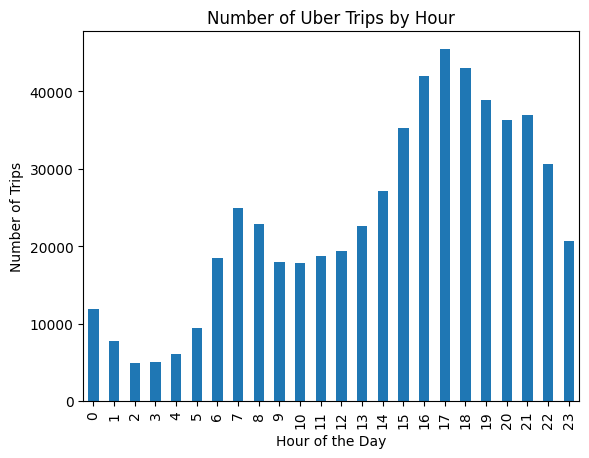

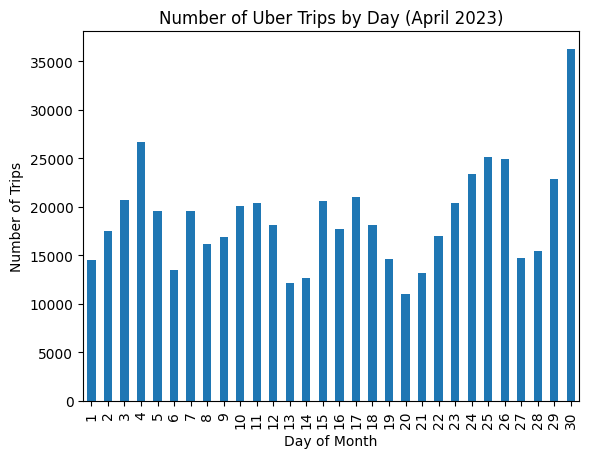

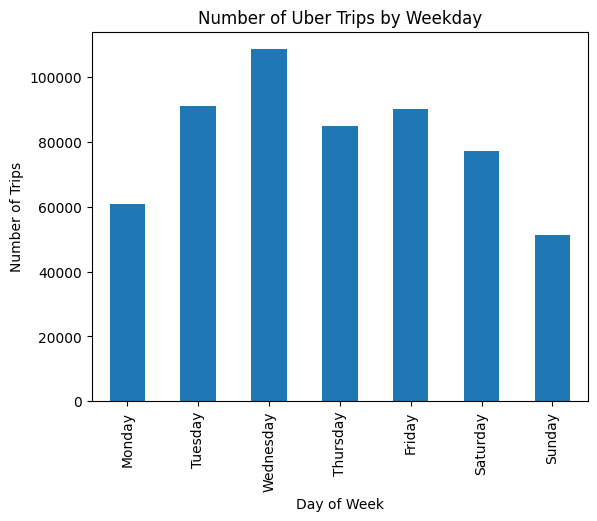

In [12]:
# Plot trips per hour

plt.figure()
hour_counts.plot(kind='bar')

plt.title("Number of Uber Trips by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Trips")

plt.show()

# Trips per day

day_counts = df['day'].value_counts().sort_index()

plt.figure()
day_counts.plot(kind='bar')

plt.title("Number of Uber Trips by Day (April 2014)")
plt.xlabel("Day of Month")
plt.ylabel("Number of Trips")

plt.show()

# Trips by weekday

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_counts = df['weekday_name'].value_counts().reindex(weekday_order)

plt.figure()
weekday_counts.plot(kind='bar')

plt.title("Number of Uber Trips by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")

plt.show()

Observations:

1. Uber trips are highest during evening hours, especially around 5 PM to 8 PM.
2. Early morning hours show the lowest activity.
3. Certain days of the week (like Friday and Saturday) have higher demand compared to others.

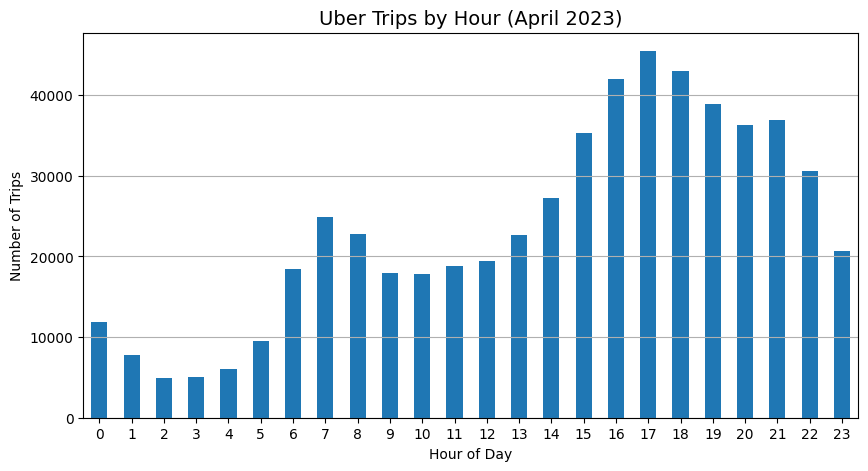

hour
0     2.109772
1     1.376223
2     0.874200
3     0.892800
4     1.079686
5     1.678606
6     3.276789
7     4.415110
8     4.046475
9     3.177766
10    3.164658
11    3.325681
12    3.441001
13    4.003961
14    4.816515
15    6.257396
16    7.440533
17    8.055573
18    7.617676
19    6.894933
20    6.420367
21    6.547910
22    5.428544
23    3.657824
Name: count, dtype: float64
hour
17    45475
18    43003
16    42003
19    38923
21    36964
Name: count, dtype: int64


In [11]:
# Improved Trips per Hour Graph

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')

plt.title("Uber Trips by Hour (April 2014)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

# Convert counts to percentage
hour_percentage = (hour_counts / hour_counts.sum()) * 100

print(hour_percentage)

# Top 5 busiest hours
top_hours = hour_counts.sort_values(ascending=False).head(5)

print(top_hours)



Observations:

1. The highest number of Uber trips occurs during evening hours, particularly between 5 PM and 8 PM.
2. Early morning hours (2 AM to 5 AM) show the lowest demand.
3. A significant percentage of total trips are concentrated in peak evening hours, indicating strong demand after typical working hours.
4. Weekends and late weekdays show higher activity compared to early weekdays.

These patterns suggest that Uber demand is strongly influenced by daily work schedules and social activity periods.

Business Insight:

Based on the analysis, Uber can optimize driver availability by increasing driver supply during peak evening hours and reducing supply during low-demand early morning hours. This can improve efficiency and reduce wait times for customers.